# Forest Fire Analysis: Machine Learning, Fuzzy Logic & Anomaly Detection

**Overview:** This study investigates whether advanced analytical methods can extract meaningful structure from the Montesinho Forest Fires dataset. The analysis evaluates three methodological pillars: (1) predictive machine learning models, (2) a fuzzy inference system modeling fire spread potential, and (3) unsupervised outlier detection. All experiments are implemented using a standardized computational pipeline.

**Core Objective:** To determine if meteorological data can reliably predict fire behavior. The study tests both continuous prediction (burned area) and categorical classification (environmental severity: LOW vs. MEDIUM), while utilizing SHAP explainability to interpret model decisions.

**Key Insight:** Predicting the exact burned area from meteorology alone is not feasible due to unrecorded external factors. However, reframing the problem to classify environmental severity yields highly accurate, interpretable results that align perfectly with rule-based fuzzy logic.

In [ ]:
!pip install scikit-fuzzy simpful xgboost shap --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 25.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, confusion_matrix
)

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Fuzzy logic
import skfuzzy as fuzz
from simpful import *

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (8,5)
sns.set(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "/content/forestfires.csv"

print("Imports OK.")


Imports OK.


In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print((df['area'] == 0).sum(), "fires burned 0 hectares")
print((df['area'] < 1).sum(), "fires burned < 1 hectare")



Dataset loaded.
Shape: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

Missing values:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64
247 fires burned 0 hectares
274 fires burned < 1 hectare


In [ ]:
data = df.copy()

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order   = ['mon','tue','wed','thu','fri','sat','sun']

data['month'] = pd.Categorical(data['month'], categories=month_order, ordered=True)
data['day']   = pd.Categorical(data['day'], categories=day_order,   ordered=True)

data['month'] = data['month'].cat.codes  # 0–11
data['day']   = data['day'].cat.codes    # 0–6

print("Encoded categorical variables.")
display(data.head())


Encoded categorical variables.


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,2,4,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,9,1,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,9,5,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,2,4,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,2,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


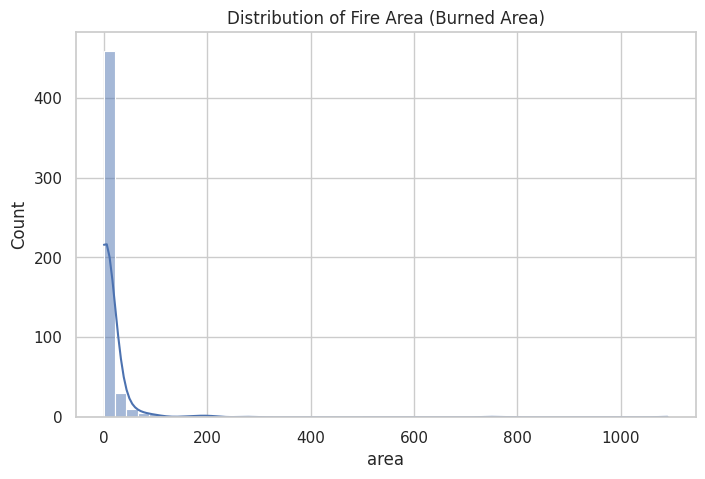

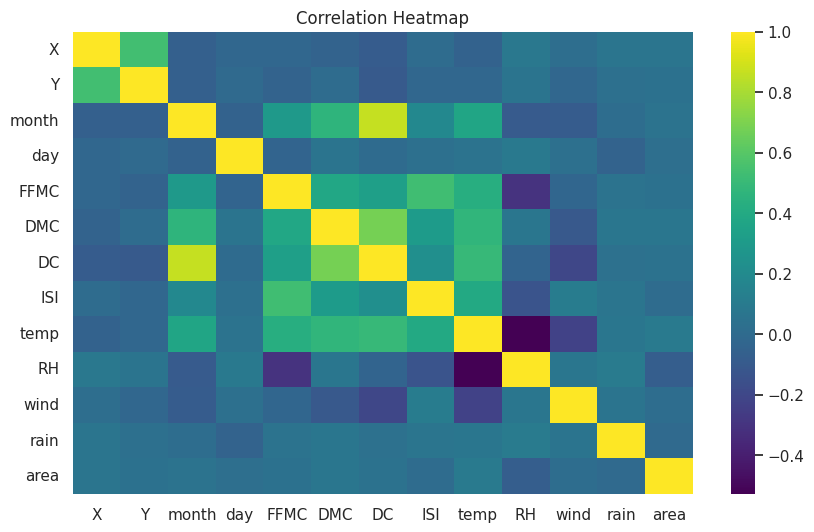

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['area'], bins=50, kde=True)
plt.title("Distribution of Fire Area (Burned Area)")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=False, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# --- ML Setup (Regression) ---

X = data.drop(columns=['area'])
y = data['area']
y_log = np.log1p(y)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_SEED
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("ML data ready.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


ML data ready.
Train shape: (413, 12)
Test shape: (104, 12)


Random Forest Results:
MSE: 2.3088506229070145
MAE: 1.2078687453293662
R² : -0.050498653730841614


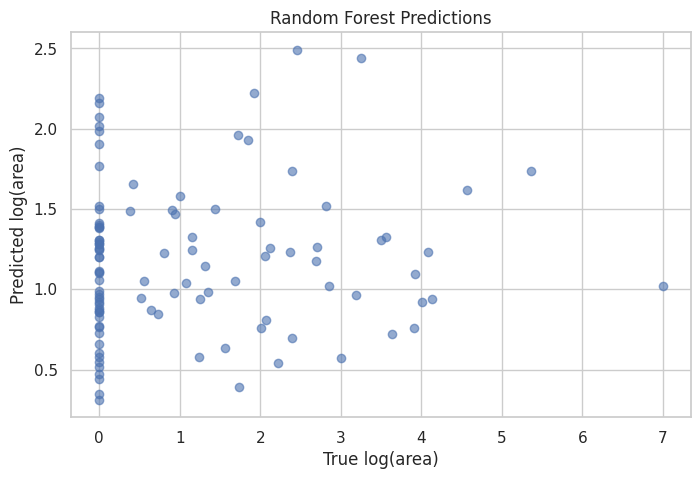

In [ ]:
# --- Random Forest Model ---

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_SEED
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2  = r2_score(y_test, rf_preds)

print("Random Forest Results:")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R² :", rf_r2)

plt.scatter(y_test, rf_preds, alpha=0.6)
plt.xlabel("True log(area)")
plt.ylabel("Predicted log(area)")
plt.title("Random Forest Predictions")
plt.show()


XGBoost Results:
MSE: 2.6225172857767016
MAE: 1.2597089885394313
R² : -0.193213129841028


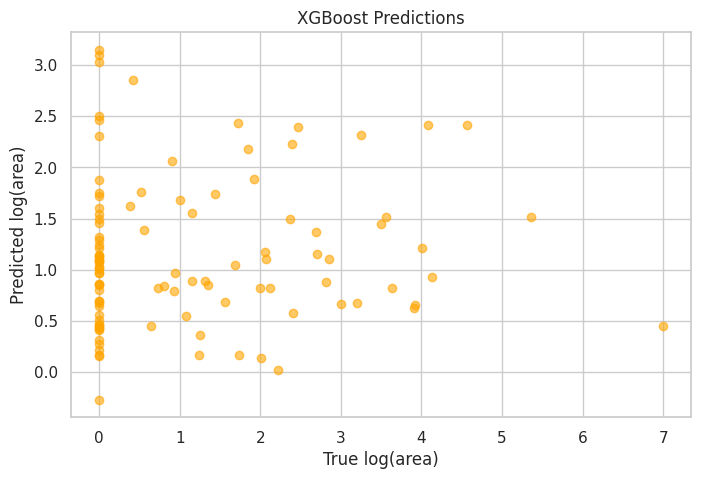

In [ ]:
# --- XGBoost Model ---

xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=RANDOM_SEED
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2  = r2_score(y_test, xgb_preds)

print("XGBoost Results:")
print("MSE:", xgb_mse)
print("MAE:", xgb_mae)
print("R² :", xgb_r2)

plt.scatter(y_test, xgb_preds, alpha=0.6, color='orange')
plt.xlabel("True log(area)")
plt.ylabel("Predicted log(area)")
plt.title("XGBoost Predictions")
plt.show()


MLP Regressor Results:
MSE: 3.8254548445413823
MAE: 1.5246863543473272
R² : -0.7405349329351969


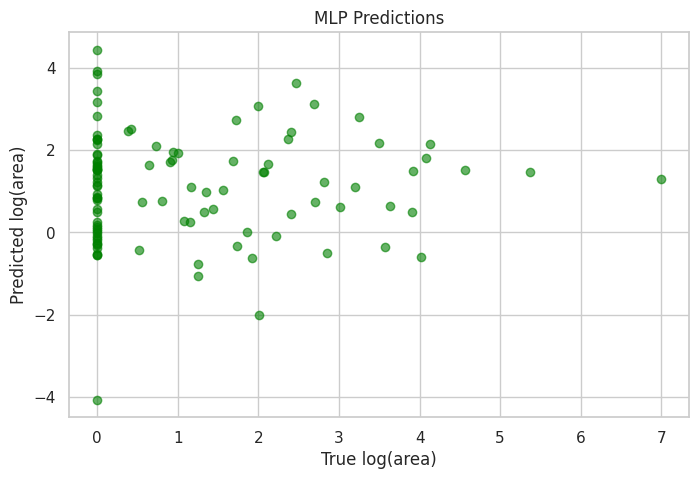

In [ ]:
# --- MLP Neural Network Model ---

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    learning_rate_init=0.001,
    random_state=RANDOM_SEED
)

mlp_model.fit(X_train_scaled, y_train)
mlp_preds = mlp_model.predict(X_test_scaled)

mlp_mse = mean_squared_error(y_test, mlp_preds)
mlp_mae = mean_absolute_error(y_test, mlp_preds)
mlp_r2  = r2_score(y_test, mlp_preds)

print("MLP Regressor Results:")
print("MSE:", mlp_mse)
print("MAE:", mlp_mae)
print("R² :", mlp_r2)

plt.scatter(y_test, mlp_preds, alpha=0.6, color='green')
plt.xlabel("True log(area)")
plt.ylabel("Predicted log(area)")
plt.title("MLP Predictions")
plt.show()


,Model,MSE,MAE,R2
0,RandomForest,2.308851,1.207869,-0.050499
1,XGBoost,2.622517,1.259709,-0.193213
2,MLP,3.825455,1.524686,-0.740535


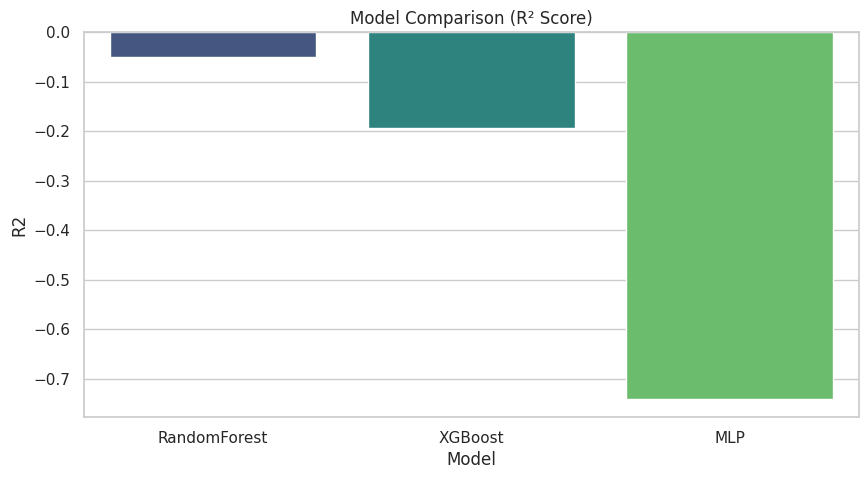

In [ ]:
results_df = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost', 'MLP'],
    'MSE': [rf_mse, xgb_mse, mlp_mse],
    'MAE': [rf_mae, xgb_mae, mlp_mae],
    'R2' : [rf_r2, xgb_r2, mlp_r2]
})

display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='R2', palette='viridis')
plt.title("Model Comparison (R² Score)")
plt.show()


In [ ]:
# --- Fuzzy Logic System ---

from simpful import FuzzySystem, LinguisticVariable, FuzzySet, Triangular_MF

fuzzy_data = data.copy()

temp_min, temp_max = fuzzy_data['temp'].min(), fuzzy_data['temp'].max()
rh_min,   rh_max   = fuzzy_data['RH'].min(),   fuzzy_data['RH'].max()
wind_min, wind_max = fuzzy_data['wind'].min(), fuzzy_data['wind'].max()
rain_min, rain_max = fuzzy_data['rain'].min(), fuzzy_data['rain'].max()
isi_min,  isi_max  = fuzzy_data['ISI'].min(),  fuzzy_data['ISI'].max()

temp_mid = 0.5 * (temp_min + temp_max)
rh_mid   = 0.5 * (rh_min + rh_max)
wind_mid = 0.5 * (wind_min + wind_max)
rain_mid = 0.5 * (rain_min + rain_max)
isi_mid  = 0.5 * (isi_min + isi_max)

FS = FuzzySystem()
FS.add_linguistic_variable(
    "Temp",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(temp_min-2, temp_min,   temp_mid), term="cold"),
            FuzzySet(function=Triangular_MF(temp_min,   temp_mid,   temp_max), term="fine"),
            FuzzySet(function=Triangular_MF(temp_mid,   temp_max,   temp_max+2), term="hot"),
        ],
        universe_of_discourse=[temp_min-2, temp_max+2]
    )
)

FS.add_linguistic_variable(
    "RH",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(rh_min-5, rh_min,  rh_mid), term="dry"),
            FuzzySet(function=Triangular_MF(rh_min,   rh_mid,  rh_max), term="comfortable"),
            FuzzySet(function=Triangular_MF(rh_mid,   rh_max,  rh_max+5), term="humid"),
        ],
        universe_of_discourse=[rh_min-5, rh_max+5]
    )
)

FS.add_linguistic_variable(
    "Wind",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(wind_min-1, wind_min,  wind_mid), term="calm"),
            FuzzySet(function=Triangular_MF(wind_min,   wind_mid,  wind_max), term="noticeable"),
            FuzzySet(function=Triangular_MF(wind_mid,   wind_max,  wind_max+1), term="extreme"),
        ],
        universe_of_discourse=[wind_min-1, wind_max+1]
    )
)

FS.add_linguistic_variable(
    "Rain",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(rain_min-1, rain_min,  rain_mid), term="clear"),
            FuzzySet(function=Triangular_MF(rain_min,   rain_mid,  rain_max), term="drizzle"),
            FuzzySet(function=Triangular_MF(rain_mid,   rain_max,  rain_max+1), term="rainstorm"),
        ],
        universe_of_discourse=[rain_min-1, rain_max+1]
    )
)

FS.add_linguistic_variable(
    "ISI",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(isi_min-5, isi_min,  isi_mid), term="slow"),
            FuzzySet(function=Triangular_MF(isi_min,   isi_mid,  isi_max), term="moderate"),
            FuzzySet(function=Triangular_MF(isi_mid,   isi_max,  isi_max+5), term="fast"),
        ],
        universe_of_discourse=[isi_min-5, isi_max+5]
    )
)

FS.add_linguistic_variable(
    "FireSpreadPotential",
    LinguisticVariable(
        [
            FuzzySet(function=Triangular_MF(0.0, 0.0, 5.0), term="LOW"),
            FuzzySet(function=Triangular_MF(0.0, 5.0, 10.0), term="MEDIUM"),
            FuzzySet(function=Triangular_MF(5.0, 10.0, 10.0), term="HIGH"),
        ],
        universe_of_discourse=[0.0, 10.0]
    )
)

RULES = [
    "IF (Temp IS hot) AND (RH IS dry) AND (ISI IS fast) THEN (FireSpreadPotential IS HIGH)",
    "IF (Temp IS hot) AND (Wind IS extreme) THEN (FireSpreadPotential IS HIGH)",
    "IF (Rain IS rainstorm) THEN (FireSpreadPotential IS LOW)",
    "IF (Temp IS fine) AND (RH IS comfortable) AND (ISI IS moderate) THEN (FireSpreadPotential IS MEDIUM)",
    "IF (RH IS humid) AND (Rain IS drizzle) THEN (FireSpreadPotential IS LOW)",
    "IF (ISI IS slow) THEN (FireSpreadPotential IS LOW)",
    "IF (Temp IS fine) AND (RH IS dry) THEN (FireSpreadPotential IS MEDIUM)",
]

FS.add_rules(RULES)

print("Fuzzy system defined with", len(RULES), "rules and custom linguistic labels.")

fuzzy_scores = []

for _, row in fuzzy_data.iterrows():
    FS.set_variable("Temp",  row['temp'])
    FS.set_variable("RH",    row['RH'])
    FS.set_variable("Wind",  row['wind'])
    FS.set_variable("Rain",  row['rain'])
    FS.set_variable("ISI",   row['ISI'])

    spread = FS.inference()["FireSpreadPotential"]
    fuzzy_scores.append(spread)

fuzzy_data['FireSpreadPotential'] = fuzzy_scores

fuzzy_data[['temp', 'RH', 'wind', 'rain', 'ISI', 'FireSpreadPotential']].head()


  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful

Fuzzy system defined with 7 rules and custom linguistic labels.


,temp,RH,wind,rain,ISI,FireSpreadPotential
0,8.2,51,6.7,0.0,5.1,3.166622
1,18.0,33,0.9,0.0,6.7,4.123369
2,14.6,33,1.3,0.0,6.7,4.123369
3,8.3,97,4.0,0.2,9.0,2.544774
4,11.4,99,1.8,0.0,9.6,2.093994


Correlation between FireSpreadPotential and log(area+1): -0.05273961939419633


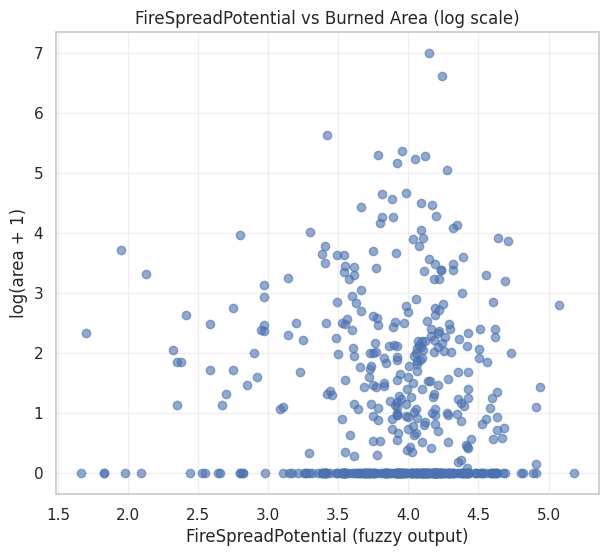

In [ ]:
log_area = np.log1p(fuzzy_data['area'])

plt.figure(figsize=(7,6))
plt.scatter(fuzzy_data['FireSpreadPotential'], log_area, alpha=0.6)
plt.xlabel("FireSpreadPotential (fuzzy output)")
plt.ylabel("log(area + 1)")
plt.title("FireSpreadPotential vs Burned Area (log scale)")
plt.grid(alpha=0.3)
corr = np.corrcoef(fuzzy_data['FireSpreadPotential'], log_area)[0, 1]
print("Correlation between FireSpreadPotential and log(area+1):", corr)
plt.show()


In [ ]:
# --- Convert FireSpreadPotential to 3 classes (LOW, MEDIUM, HIGH) ---

def classify_spread(x):
    if x < 3.3:
        return "LOW"
    elif x < 6.6:
        return "MEDIUM"
    else:
        return "HIGH"

fuzzy_data['SpreadClass'] = fuzzy_data['FireSpreadPotential'].apply(classify_spread)

fuzzy_data[['FireSpreadPotential', 'SpreadClass']].head()

print(fuzzy_data['SpreadClass'].value_counts())


SpreadClass
MEDIUM    462
LOW        55
Name: count, dtype: int64


In [ ]:
clf_data = fuzzy_data[fuzzy_data['SpreadClass'].isin(["LOW", "MEDIUM"])].copy()
clf_data['SpreadBinary'] = clf_data['SpreadClass'].map({"LOW": 0, "MEDIUM": 1})

clf_data[['FireSpreadPotential', 'SpreadClass', 'SpreadBinary']].head()
print(clf_data['SpreadClass'].value_counts())


SpreadClass
MEDIUM    462
LOW        55
Name: count, dtype: int64


Random Forest Classification Results:
Accuracy: 0.9807692307692307
              precision    recall  f1-score   support

         LOW       1.00      0.82      0.90        11
      MEDIUM       0.98      1.00      0.99        93

    accuracy                           0.98       104
   macro avg       0.99      0.91      0.94       104
weighted avg       0.98      0.98      0.98       104



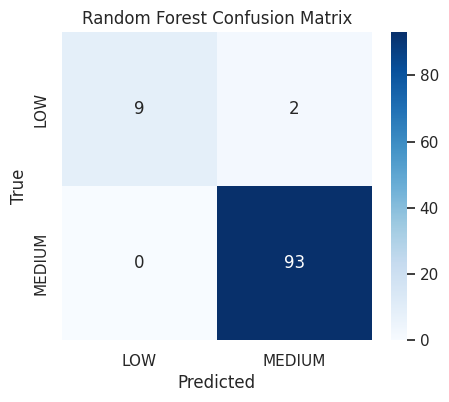

In [ ]:
# --- Binary Classification: Random Forest Classifier ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

X = clf_data[['temp', 'RH', 'wind', 'rain', 'ISI', 'FFMC', 'DMC', 'DC', 'X', 'Y']]
y = clf_data['SpreadBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

clf_rf.fit(X_train_scaled, y_train)
y_pred = clf_rf.predict(X_test_scaled)

print("Random Forest Classification Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["LOW", "MEDIUM"]))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOW","MEDIUM"],
            yticklabels=["LOW","MEDIUM"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


XGBoost Classification Results:
Accuracy: 0.9903846153846154
              precision    recall  f1-score   support

         LOW       1.00      0.91      0.95        11
      MEDIUM       0.99      1.00      0.99        93

    accuracy                           0.99       104
   macro avg       0.99      0.95      0.97       104
weighted avg       0.99      0.99      0.99       104



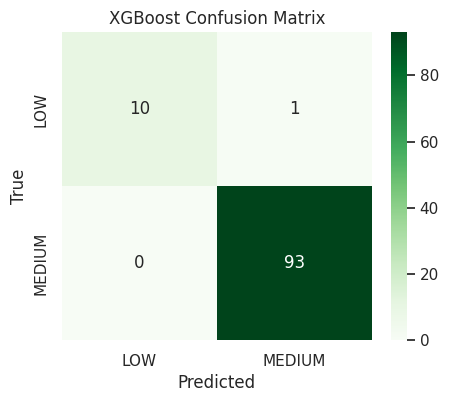

In [ ]:
# --- Binary Classification: XGBoost Classifier ---

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    scale_pos_weight=(len(y_train) / sum(y_train == 0)),  # handle imbalance
    random_state=42,
    eval_metric="logloss"
)

clf_xgb.fit(X_train_scaled, y_train)
y_pred = clf_xgb.predict(X_test_scaled)

print("XGBoost Classification Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["LOW", "MEDIUM"]))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["LOW","MEDIUM"],
            yticklabels=["LOW","MEDIUM"])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


MLP Classification Results:
Accuracy: 0.9615384615384616
              precision    recall  f1-score   support

         LOW       0.82      0.82      0.82        11
      MEDIUM       0.98      0.98      0.98        93

    accuracy                           0.96       104
   macro avg       0.90      0.90      0.90       104
weighted avg       0.96      0.96      0.96       104



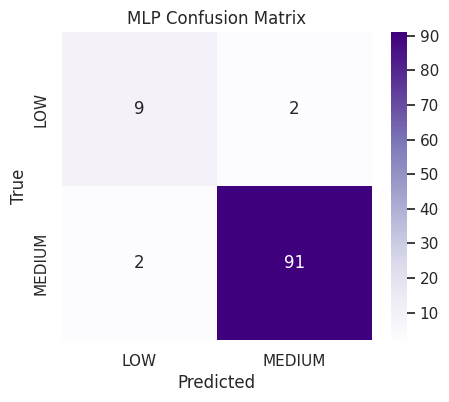

In [ ]:
# --- Binary Classification: MLP Neural Network ---

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Scaling is required for MLP:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MLP model
clf_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=600,
    random_state=42,
)

clf_mlp.fit(X_train_scaled, y_train)
y_pred = clf_mlp.predict(X_test_scaled)

print("MLP Classification Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["LOW", "MEDIUM"]))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["LOW","MEDIUM"],
            yticklabels=["LOW","MEDIUM"])
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# --- Model Comparison Table ---

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP"],
    "Accuracy": [
        0.9807,
        0.9903,
        0.9615
    ],
    "LOW Recall": [
        0.82,
        0.91,
        0.82
    ],
    "MEDIUM Recall": [
        1.00,
        1.00,
        0.98
    ]
})

comparison_df


,Model,Accuracy,LOW Recall,MEDIUM Recall
0,Random Forest,0.9807,0.82,1.00
1,XGBoost,0.9903,0.91,1.00
2,MLP,0.9615,0.82,0.98


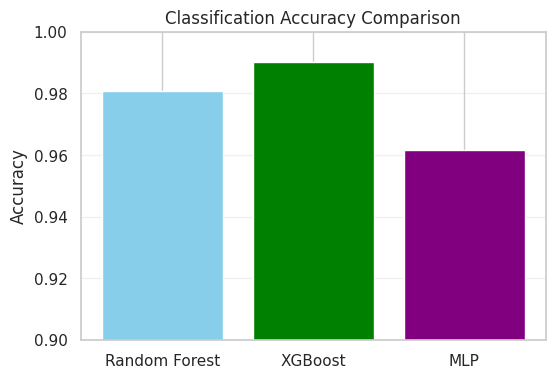

In [ ]:

plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"], color=["skyblue","green","purple"])
plt.ylim(0.90, 1.0)
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()


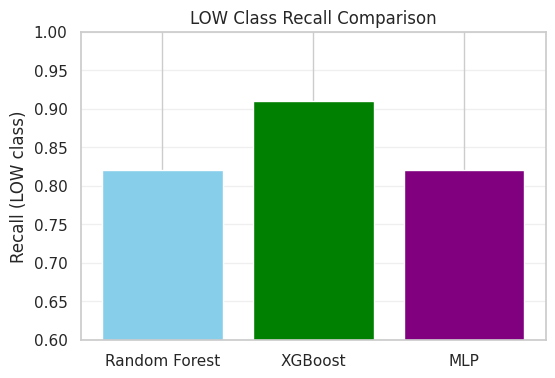

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["LOW Recall"], color=["skyblue","green","purple"])
plt.ylim(0.6, 1.0)
plt.ylabel("Recall (LOW class)")
plt.title("LOW Class Recall Comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()


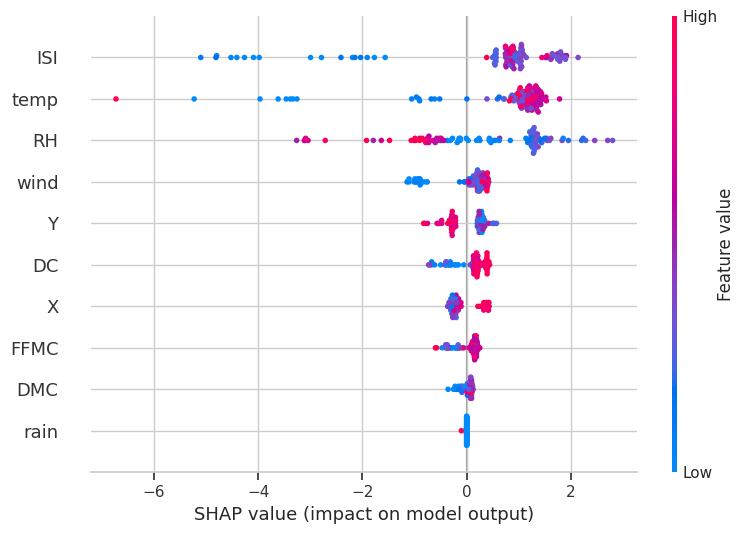

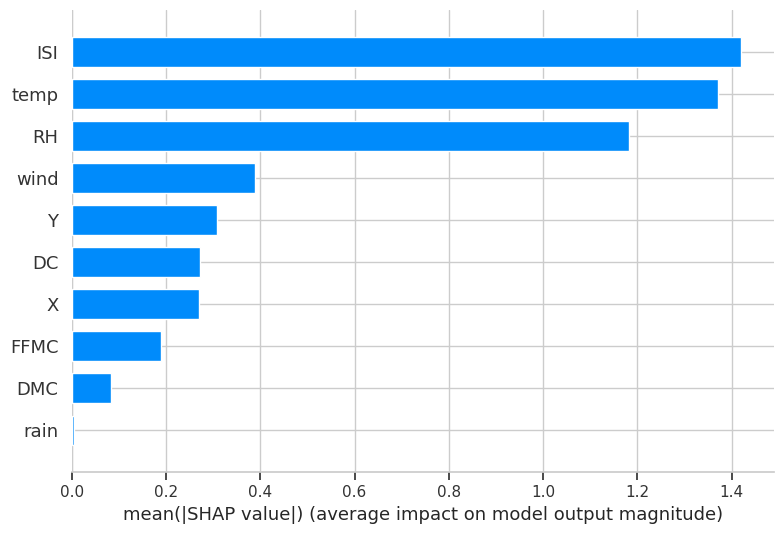

In [ ]:
shap.initjs()

import shap
feature_names = X.columns

explainer = shap.TreeExplainer(clf_xgb)

shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar")

sample_index = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_scaled[sample_index],
    feature_names=feature_names,
)


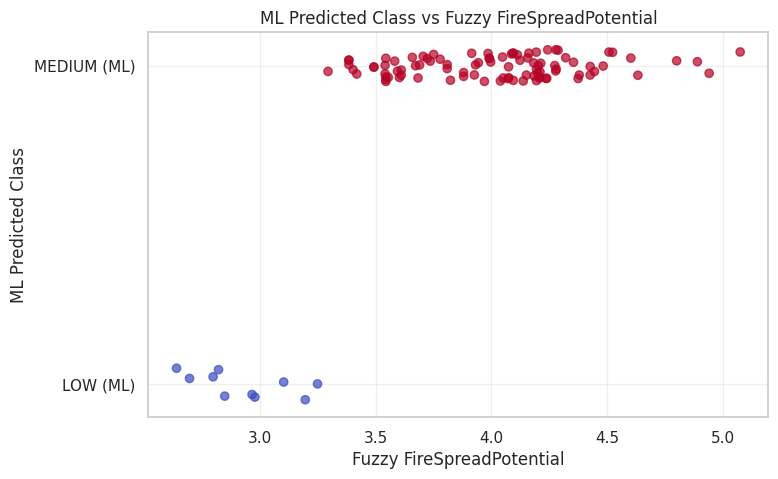


 Agreement between ML and Fuzzy Classes: 

ML         0     1
Fuzzy             
LOW     0.91  0.09
MEDIUM  0.00  1.00


In [ ]:
# --- ML vs Fuzzy Logic Comparison ---

import numpy as np
import matplotlib.pyplot as plt

ml_preds = clf_xgb.predict(X_test_scaled)

fuzzy_test_values = fuzzy_data.loc[X_test.index, "FireSpreadPotential"].values

jitter = (np.random.rand(len(ml_preds)) - 0.5) * 0.1
ml_preds_jittered = ml_preds + jitter

plt.figure(figsize=(8,5))
plt.scatter(fuzzy_test_values, ml_preds_jittered,
            c=ml_preds, cmap="coolwarm", alpha=0.7)

plt.yticks([0, 1], ["LOW (ML)", "MEDIUM (ML)"])
plt.xlabel("Fuzzy FireSpreadPotential")
plt.ylabel("ML Predicted Class")
plt.title("ML Predicted Class vs Fuzzy FireSpreadPotential")
plt.grid(alpha=0.3)
plt.show()

comparison_df = pd.DataFrame({
    "Fuzzy": fuzzy_test_values,
    "ML": ml_preds
})
comparison_df["FuzzyClass"] = comparison_df["Fuzzy"].apply(
    lambda x: "LOW" if x < 3.3 else "MEDIUM"
)

# Alignment table
print("\n Agreement between ML and Fuzzy Classes: \n")
print(pd.crosstab(comparison_df["FuzzyClass"], comparison_df["ML"],
                  rownames=["Fuzzy"], colnames=["ML"],
                  normalize="index").round(2))


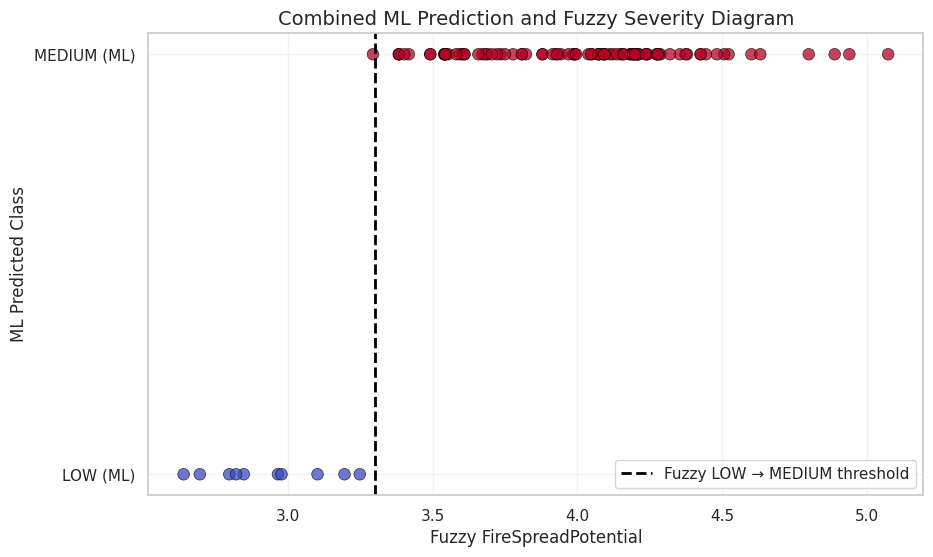

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    fuzzy_test_values, ml_preds,
    c=ml_preds, cmap="coolwarm",
    alpha=0.75, s=70, edgecolors="black", linewidth=0.5
)

plt.yticks([0,1], ["LOW (ML)", "MEDIUM (ML)"])

plt.axvline(x=3.3, color="black", linestyle="--", linewidth=2,
            label="Fuzzy LOW → MEDIUM threshold")

plt.xlabel("Fuzzy FireSpreadPotential", fontsize=12)
plt.ylabel("ML Predicted Class", fontsize=12)
plt.title("Combined ML Prediction and Fuzzy Severity Diagram", fontsize=14)
plt.grid(alpha=0.25)
plt.legend()

plt.show()


Isolation Forest Anomalies:
IsoForest
 1    491
-1     26
Name: count, dtype: int64


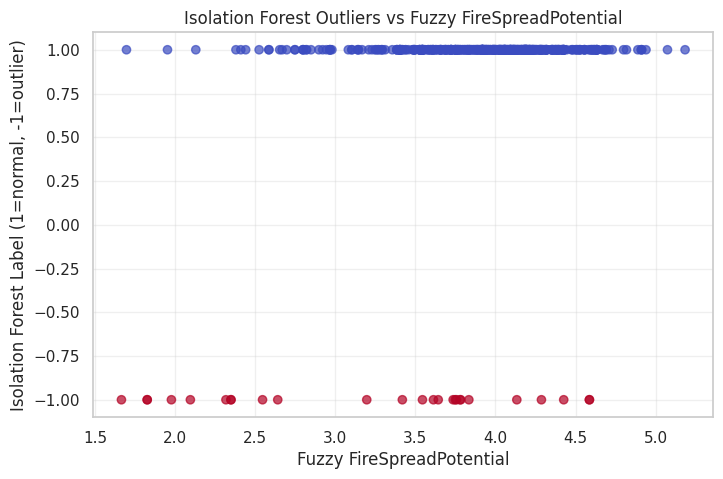

In [ ]:
# --- Outlier Detection: Isolation Forest ---

from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

X_env = clf_data[['temp', 'RH', 'wind', 'rain', 'ISI', 'FFMC', 'DMC', 'DC', 'X', 'Y']]

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso.fit(X_env)
iso_labels = iso.predict(X_env)     # 1 = normal, -1 = anomaly

clf_data["IsoForest"] = iso_labels

print("Isolation Forest Anomalies:")
print(clf_data["IsoForest"].value_counts())

plt.figure(figsize=(8,5))
plt.scatter(
    fuzzy_data.loc[clf_data.index, "FireSpreadPotential"],
    clf_data["IsoForest"],
    c=(clf_data["IsoForest"] == -1),
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Fuzzy FireSpreadPotential")
plt.ylabel("Isolation Forest Label (1=normal, -1=outlier)")
plt.title("Isolation Forest Outliers vs Fuzzy FireSpreadPotential")
plt.grid(alpha=0.3)
plt.show()


Local Outlier Factor Anomalies:
LOF
 1    491
-1     26
Name: count, dtype: int64


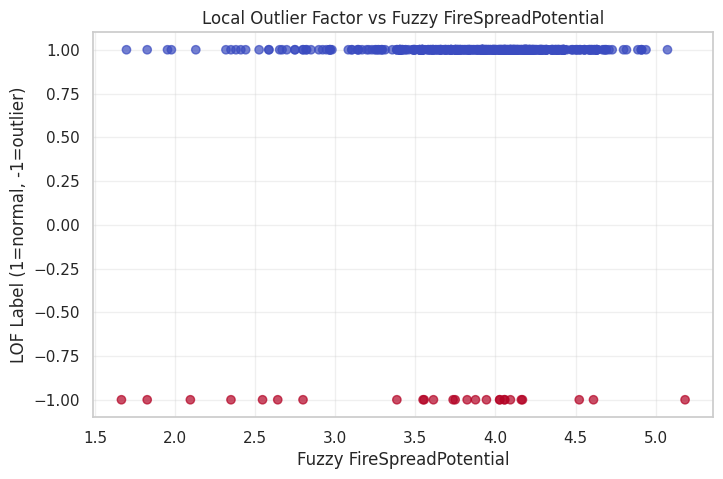

In [ ]:
# --- Outlier Detection: Local Outlier Factor (LOF) ---

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False
)

lof_labels = lof.fit_predict(X_env)
clf_data["LOF"] = lof_labels

print("Local Outlier Factor Anomalies:")
print(clf_data["LOF"].value_counts())

plt.figure(figsize=(8,5))
plt.scatter(
    fuzzy_data.loc[clf_data.index, "FireSpreadPotential"],
    clf_data["LOF"],
    c=(clf_data["LOF"] == -1),
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Fuzzy FireSpreadPotential")
plt.ylabel("LOF Label (1=normal, -1=outlier)")
plt.title("Local Outlier Factor vs Fuzzy FireSpreadPotential")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# --- Fuzzy Class vs Outliers ---
fuzzy_classes = clf_data['SpreadClass']   # LOW or MEDIUM

iso_crosstab = pd.crosstab(fuzzy_classes, clf_data['IsoForest'])
print("Isolation Forest vs Fuzzy Class:")
print(iso_crosstab, "\n")

lof_crosstab = pd.crosstab(fuzzy_classes, clf_data['LOF'])
print("LOF vs Fuzzy Class:")
print(lof_crosstab, "\n")

print("Isolation Forest Outlier Percentages:")
print((iso_crosstab.div(iso_crosstab.sum(axis=1), axis=0) * 100).round(2), "\n")

print("LOF Outlier Percentages:")
print((lof_crosstab.div(lof_crosstab.sum(axis=1), axis=0) * 100).round(2), "\n")


Isolation Forest vs Fuzzy Class:
IsoForest    -1    1
SpreadClass         
LOW          11   44
MEDIUM       15  447 

LOF vs Fuzzy Class:
LOF          -1    1
SpreadClass         
LOW           7   48
MEDIUM       19  443 

Isolation Forest Outlier Percentages:
IsoForest       -1      1
SpreadClass              
LOW          20.00  80.00
MEDIUM        3.25  96.75 

LOF Outlier Percentages:
LOF             -1      1
SpreadClass              
LOW          12.73  87.27
MEDIUM        4.11  95.89 



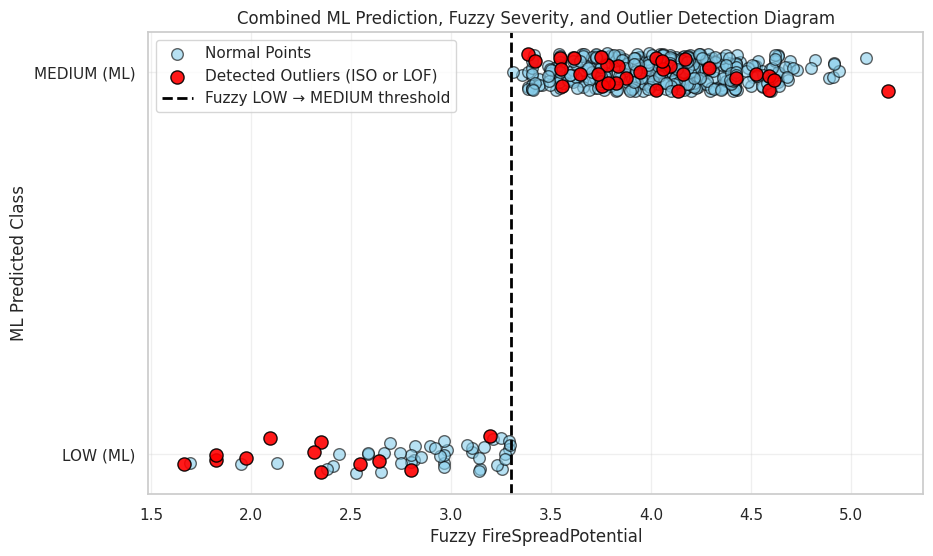

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
combined_outliers = (clf_data["IsoForest"] == -1) | (clf_data["LOF"] == -1)

clf_data["CombinedOutlier"] = combined_outliers.astype(int)

fuzzy_vals = fuzzy_data.loc[clf_data.index, "FireSpreadPotential"]
ml_preds_plot = clf_data["SpreadBinary"]  # 0 = LOW, 1 = MEDIUM
outlier_flags = clf_data["CombinedOutlier"]

ml_preds_jittered = ml_preds_plot + (np.random.rand(len(ml_preds_plot)) - 0.5) * 0.1

plt.figure(figsize=(10,6))

plt.scatter(
    fuzzy_vals[outlier_flags == 0],
    ml_preds_jittered[outlier_flags == 0],
    color="skyblue",
    label="Normal Points",
    alpha=0.6,
    edgecolors="black",
    s=70
)

plt.scatter(
    fuzzy_vals[outlier_flags == 1],
    ml_preds_jittered[outlier_flags == 1],
    color="red",
    label="Detected Outliers (ISO or LOF)",
    alpha=0.9,
    edgecolors="black",
    s=90
)

# Fuzzy threshold line
plt.axvline(x=3.3, color="black", linestyle="--", linewidth=2,
            label="Fuzzy LOW → MEDIUM threshold")

plt.yticks([0,1], ["LOW (ML)", "MEDIUM (ML)"])
plt.xlabel("Fuzzy FireSpreadPotential")
plt.ylabel("ML Predicted Class")
plt.title("Combined ML Prediction, Fuzzy Severity, and Outlier Detection Diagram")

plt.grid(alpha=0.3)
plt.legend()
plt.show()
